## Preliminares

In [1]:
import pandas as pd
import numpy as np
from src.config import data_folder
%load_ext autoreload
%autoreload 2
from src.transform import *

In [2]:
# Abrir archivo raw_data
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")

# Se asegura el ordenamiento por fecha
df = df.sort_values(by='Date').reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11372 entries, 0 to 11371
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         11372 non-null  datetime64[ns]
 1   Ticker                       11372 non-null  object        
 2   Close                        11372 non-null  float64       
 3   Open                         11372 non-null  float64       
 4   Volume                       11372 non-null  float64       
 5   DateAdded                    6705 non-null   object        
 6   Sector                       11372 non-null  object        
 7   Industry                     11372 non-null  object        
 8   TotalRevenue                 11372 non-null  float64       
 9   GrossProfit                  10519 non-null  float64       
 10  OperatingIncome              11372 non-null  float64       
 11  NetIncome                    11372 non-nu

* Para mejorar la visualización de los datos, se expresan las columnas financieras y volumen en millones:

In [3]:
df = financieras_en_millones(df)

In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,11372,2023-08-23 23:59:06.816743168,2020-09-01 00:00:00,2022-03-01 00:00:00,2023-09-01 00:00:00,2025-03-01 00:00:00,2026-06-01 00:00:00,NaN
Close,11372.0,1040.632239,0.57,41.010419,82.728504,165.380489,775000.0,22865.077155
Open,11372.0,1008.193167,0.53,40.525032,81.59261,161.329193,775648.0,22114.560395
Volume,11372.0,329.35621,0.0002,44.459425,103.586127,258.802775,36280.458,1251.880973
TotalRevenue,11372.0,6593.381045,-12134.0,1275.91075,2386.5,5278.8,227173.0,14899.692411
GrossProfit,10519.0,2361.834557,-24353.0,422.4545,831.622,1828.5,137192.0,6375.388808
OperatingIncome,11372.0,967.03061,-55512.0,125.3455,303.581,820.05,77648.0,2944.934098
NetIncome,11372.0,718.475912,-43621.0,65.47875,199.0,581.0,62578.0,2672.06322
EBITDA,1885.0,1561.779546,-16168.444,197.767,466.778,1202.0,84427.0,5209.528381
BasicAverageShares,11326.0,641.974123,0.00021,95.826629,219.801,550.57775,30864.0,1743.662701


## Corrección de errores y valores perdidos

In [5]:
# Se analiza el siguiente registro con valores extremadamente elevados en el estado de resultados
registro_iiin = df[(df['Ticker'] == 'IIIN') & (df['Date'] == '2021-12-01')]

# Mostrar el resultado
print(registro_iiin.T)

                                            2016
Date                         2021-12-01 00:00:00
Ticker                                      IIIN
Close                                   28.25313
Open                                   31.382216
Volume                                    7.3179
DateAdded                                   None
Sector                               Industrials
Industry                       Metal Fabrication
TotalRevenue                             171.258
GrossProfit                               39.919
OperatingIncome                           32.598
NetIncome                                 25.152
EBITDA                                       NaN
BasicAverageShares                        19.344
CashAndCashEquivalents                   89884.0
CurrentDebt                                  NaN
LongTermDebt                                 NaN
TotalDebt                                    NaN
StockholdersEquity                      302038.0
TotalAssets         

* Se observa una desconexión en los valores del Balance General, estan multiplicados por 1.000.
* El caso se detecto ya que arrojaba valores extremos en las métricas.

Se corrige dividiendo las columnas afectadas por 1.000:

In [6]:
mask_iiin = (df['Ticker'] == 'IIIN') & (df['Date'] == '2021-12-01')

# Columnas del balance que tienen el error
columnas_balance = [
    'CashAndCashEquivalents', 
    'TotalAssets', 
    'StockholdersEquity', 
    'CurrentAssets', 
    'CurrentLiabilities'
]

# Se dividen por 1000
df.loc[mask_iiin, columnas_balance] /= 1000

Anomalías de signo: 

Las siguientes variables no pueden ser negativas:
* `TotalRevenue`
* `CurrentDebt`
* `LongTermDebt`
* `DepreciationAndAmortization`

In [7]:
# Visualizar casos de TotalRevenue negativo
condicion = df['TotalRevenue'] < 0
cols_a_visualizar = ['Ticker', 'Date', 'TotalRevenue', 'OperatingIncome']
anomalias = df.loc[condicion, cols_a_visualizar]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

     Ticker       Date  TotalRevenue  OperatingIncome
726    AVNT 2021-03-01     -30.20000       -12.700000
891     ALB 2021-03-01   -1790.31392      -114.758843
976     XPO 2021-03-01   -1093.00000        14.000000
2211    EMR 2021-12-01    -357.00000      -206.000000
2728    BHF 2022-03-01    -150.00000      2266.000000
2770    XPO 2022-03-01   -2243.00000      -189.000000
2825   FTNT 2022-03-01   -1415.00000       213.700000
4113      J 2022-12-01   -1258.70300       -69.426000
4588    BHF 2023-03-01    -127.00000        40.000000
4643    BAX 2023-03-01    -704.00000      -285.000000
4709    CNA 2023-03-01   -3542.00000     -4648.000000
4833     GE 2023-03-01  -12134.00000      4010.000000
5328    NGL 2023-06-01    -967.05000        65.932000
5597    WDC 2023-09-01   -3391.00000        93.000000
6050      J 2023-12-01   -1212.28200      -120.924000
6479   OTIS 2023-12-01   -3543.00000      -516.000000
6496    DAN 2024-03-01    -448.00000      -387.000000
6571   NDAQ 2024-03-01    -5

* No se puede concluir que se traten de alteraciones de signo en el parseo de datos de simFin. Se observa en 2 casos que el valor absoluto de `TotalRevenue` es mayor que `OperatingIncome`, es imposible que los resultados sean mayores que las ventas.

Se opta por asignar todos estos valores anómalos a NaN.

In [8]:
df['TotalRevenue'] = np.where(df['TotalRevenue'] < 0, np.nan, df['TotalRevenue'])

* Casos de deuda negativa: se calcula "PasivoImplicito", que surge de aplicar la ecuación contable fundamental `Activo` = `Pasivo` + `Patrimonio Neto`

In [9]:
df['PasivoImplicito'] = df['TotalAssets'] - df['StockholdersEquity']

condicion = (df['CurrentDebt'] < 0) | (df['LongTermDebt'] < 0)
cols_a_visualizar = ['Ticker', 'Date', 'TotalDebt', 'CurrentDebt', 'LongTermDebt', 'PasivoImplicito']
anomalias = df.loc[condicion, cols_a_visualizar]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

     Ticker       Date  TotalDebt  CurrentDebt  LongTermDebt  PasivoImplicito
3519    IEP 2022-09-01        NaN     -746.000      7134.000        15991.000
4295    IEP 2022-12-01        NaN     -745.000      7127.000        16908.000
6730   STLD 2024-03-01        NaN      459.987     -3286.537          171.287
7154   STLD 2024-06-01        NaN      425.696     -3570.028         -203.283
8039   STLD 2024-12-01        NaN      882.013     -3997.348         -218.698
8716    TXN 2025-03-01        NaN      750.000    -28049.000       -22289.000
Cantidad de casos: 6


* Se observa que la ecuación contable fundamental no se cumple. 

Se decide eliminar estos registros "tóxicos" del dataset.

In [10]:
condicion = (df['CurrentDebt'] < 0) | (df['LongTermDebt'] < 0)
df = df[~condicion].reset_index(drop=True)
df = df.drop(columns= 'PasivoImplicito')

* Casos de negativos en `DepreciationAndAmortization`: 

se analizan los casos considerando la ecuación `EBITDA` = `OperatingIncome` + `DepreciationAndAmortization`

In [11]:
condicion = df['DepreciationAndAmortization'] < 0
cols_a_visualizar = ['Ticker', 'Date', 'DepreciationAndAmortization', 'EBITDA', 'OperatingIncome']
anomalias = df.loc[condicion, cols_a_visualizar]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

      Ticker       Date  DepreciationAndAmortization  EBITDA  OperatingIncome
0       SNPS 2020-09-01                       -9.931     NaN          208.621
2         DY 2020-09-01                      -44.129     NaN           54.482
4       BURL 2020-09-01                      -54.404     NaN          -81.224
5       ADBE 2020-09-01                      -41.000     NaN         1069.000
9        TGT 2020-09-01                     -542.000     NaN         2300.000
...      ...        ...                          ...     ...              ...
9477     DVN 2025-06-01                     -912.000     NaN         1052.000
9495     KMX 2025-09-01                      -65.739     NaN          168.241
9732    ORCL 2025-09-01                     -544.000     NaN         5191.000
9915    ADBE 2025-09-01                      -41.000     NaN         2109.000
10931    GME 2026-06-01                       -0.300   144.9          144.900

[4262 rows x 5 columns]
Cantidad de casos: 4262


* Los datos que provienen de `simFin` utilizan signo negativo para esta columna, lo cual es incorrecto. 

* Dichos valores serán convertidos a positivos.

A continuación se verifican si hay datos negativos que vengan de yfinance (con EBITDA):

In [12]:
condicion = (df['DepreciationAndAmortization'] < 0) & (df['EBITDA'].notna())
cols_a_visualizar = ['Ticker', 'Date', 'DepreciationAndAmortization', 'EBITDA', 'OperatingIncome']
anomalias = df.loc[condicion, cols_a_visualizar]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

      Ticker       Date  DepreciationAndAmortization  EBITDA  OperatingIncome
10931    GME 2026-06-01                         -0.3   144.9            144.9
Cantidad de casos: 1


* En este caso se observa que el valor implicito de `DepreciationAndAmortization` es igual a cero (EBITDA = OperatingIncome). 
* El valor de -0.3 pudo haberse tratado de un pequeño "ajuste contable", $300.000 dólares para una compañia del tamaño de `GameStop` es contablemente irrelevante.

Se reemplaza dicho valor por cero:

In [13]:
df.loc[condicion,'DepreciationAndAmortization'] = 0

In [14]:
# Ahora se convierten a positivos los restantes
df['DepreciationAndAmortization'] = df['DepreciationAndAmortization'].abs()

# Verificar cambios
condicion = df['DepreciationAndAmortization'] < 0
cols_a_visualizar = ['Ticker', 'Date', 'DepreciationAndAmortization', 'EBITDA', 'OperatingIncome']
anomalias = df.loc[condicion, cols_a_visualizar]
print(anomalias)
print("Cantidad de casos:", len(anomalias))

Empty DataFrame
Columns: [Ticker, Date, DepreciationAndAmortization, EBITDA, OperatingIncome]
Index: []
Cantidad de casos: 0


In [15]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,11366,2023-08-23 22:09:00.981875712,2020-09-01 00:00:00,2022-03-01 00:00:00,2023-09-01 00:00:00,2025-03-01 00:00:00,2026-06-01 00:00:00,NaN
Close,11366.0,1041.128518,0.57,41.012919,82.713295,165.388599,775000.0,22871.101771
Open,11366.0,1008.668907,0.53,40.526938,81.584925,161.399801,775648.0,22120.387424
Volume,11366.0,329.456547,0.0002,44.462575,103.6049,258.864325,36280.458,1252.197292
TotalRevenue,11341.0,6615.658959,0.756217,1278.859,2394.271,5297.2,227173.0,14912.315086
GrossProfit,10513.0,2362.674765,-24353.0,422.484,832.2,1829.0,137192.0,6377.090679
OperatingIncome,11366.0,967.292552,-55512.0,125.35625,303.5175,820.15,77648.0,2945.66569
NetIncome,11366.0,718.65458,-43621.0,65.491,199.0,581.0,62578.0,2672.73675
EBITDA,1885.0,1561.779546,-16168.444,197.767,466.778,1202.0,84427.0,5209.528381
BasicAverageShares,11320.0,642.136198,0.00021,95.762879,219.801,550.64475,30864.0,1744.099701


In [16]:
# Incidencia de missings
mostrar_missings(df)

TotalDebt                      0.835738
EBITDA                         0.834154
FreeCashFlow                   0.834154
DepreciationAndAmortization    0.462872
DateAdded                      0.410435
CurrentDebt                    0.236847
GrossProfit                    0.075048
LongTermDebt                   0.055604
CurrentAssets                  0.048126
CurrentLiabilities             0.047862
CapitalExpenditure             0.026922
BasicAverageShares             0.004047
CashAndCashEquivalents         0.003695
FinancingCashFlow              0.003255
OperatingCashFlow              0.002639
TotalRevenue                   0.002200
InvestingCashFlow              0.002200
StockholdersEquity             0.001408
TotalAssets                    0.001144
NetIncome                      0.000000
Date                           0.000000
OperatingIncome                0.000000
Sector                         0.000000
Industry                       0.000000
Volume                         0.000000


* Se imputan parte de los NaNs en Variables Financieras antes de calcular métricas, 
mediante las relaciones contables entre ellas:

In [17]:
df_acc_imputed = imputar_equivalencias_financieras(df)
mostrar_missings(df_acc_imputed)

DateAdded                      0.410435
TotalDebt                      0.208253
CurrentDebt                    0.206845
GrossProfit                    0.075048
LongTermDebt                   0.053933
CurrentAssets                  0.048126
CurrentLiabilities             0.047862
CapitalExpenditure             0.026922
FreeCashFlow                   0.025339
BasicAverageShares             0.004047
CashAndCashEquivalents         0.003695
FinancingCashFlow              0.003255
OperatingCashFlow              0.002639
TotalRevenue                   0.002200
InvestingCashFlow              0.002200
StockholdersEquity             0.001408
TotalAssets                    0.001144
NetIncome                      0.000000
Close                          0.000000
Open                           0.000000
Date                           0.000000
OperatingIncome                0.000000
Sector                         0.000000
Industry                       0.000000
Volume                         0.000000


* Se crea feature `YearsSinceAdded`:

In [18]:
#  Pasar DateAdded a formato datetime, los NaN se vuelven NaT (not a time)
df_acc_imputed['DateAdded'] = pd.to_datetime(df_acc_imputed['DateAdded'], errors='coerce')
# Convertir a YearsSinceAdded, aqui los nulos regresan a NaN
df_acc_imputed['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_acc_imputed['DateAdded']).dt.days / 365.25), 0)

# 3. Se asignan a cero años los tickers que no pertenecen al Índice S&P 500
df_acc_imputed['YearsSinceAdded'] = df_acc_imputed['YearsSinceAdded'].fillna(0)

# Eliminar la columna original
df_acc_imputed.drop('DateAdded', axis=1, inplace=True)
mostrar_missings(df_acc_imputed)

TotalDebt                      0.208253
CurrentDebt                    0.206845
GrossProfit                    0.075048
LongTermDebt                   0.053933
CurrentAssets                  0.048126
CurrentLiabilities             0.047862
CapitalExpenditure             0.026922
FreeCashFlow                   0.025339
BasicAverageShares             0.004047
CashAndCashEquivalents         0.003695
FinancingCashFlow              0.003255
OperatingCashFlow              0.002639
TotalRevenue                   0.002200
InvestingCashFlow              0.002200
StockholdersEquity             0.001408
TotalAssets                    0.001144
EBITDA                         0.000000
NetIncome                      0.000000
Close                          0.000000
Open                           0.000000
Ticker                         0.000000
Date                           0.000000
OperatingIncome                0.000000
Industry                       0.000000
Volume                         0.000000


In [19]:
# Se imputan las columnas financieras originales, por su media o mediana móvil según sus asimetrías
df_fin_imputed = imputar_numericas(df_acc_imputed)
mostrar_missings(df_fin_imputed)

TotalDebt                      0.013373
CurrentDebt                    0.011614
GrossProfit                    0.000352
CurrentAssets                  0.000176
LongTermDebt                   0.000176
CurrentLiabilities             0.000176
Industry                       0.000000
Volume                         0.000000
Open                           0.000000
Date                           0.000000
Close                          0.000000
Ticker                         0.000000
EBITDA                         0.000000
NetIncome                      0.000000
OperatingIncome                0.000000
TotalRevenue                   0.000000
Sector                         0.000000
BasicAverageShares             0.000000
StockholdersEquity             0.000000
CashAndCashEquivalents         0.000000
TotalAssets                    0.000000
OperatingCashFlow              0.000000
InvestingCashFlow              0.000000
FinancingCashFlow              0.000000
FreeCashFlow                   0.000000


* Se aplica forward fill y back fill para cubrir posibles huecos (es necesario que no hayan valores perdidos antes de calcular los valores TTM):

In [20]:
df_fin_imputed = aplicar_fill(df_fin_imputed, limite=None)
mostrar_missings(df_fin_imputed)

Date                           0.0
Ticker                         0.0
Close                          0.0
Open                           0.0
Volume                         0.0
Sector                         0.0
Industry                       0.0
TotalRevenue                   0.0
GrossProfit                    0.0
OperatingIncome                0.0
NetIncome                      0.0
EBITDA                         0.0
BasicAverageShares             0.0
CashAndCashEquivalents         0.0
CurrentDebt                    0.0
LongTermDebt                   0.0
TotalDebt                      0.0
StockholdersEquity             0.0
TotalAssets                    0.0
CurrentAssets                  0.0
CurrentLiabilities             0.0
OperatingCashFlow              0.0
InvestingCashFlow              0.0
FinancingCashFlow              0.0
FreeCashFlow                   0.0
CapitalExpenditure             0.0
DepreciationAndAmortization    0.0
YearsSinceAdded                0.0
dtype: float64

* Se convierten las variables de flujo trimestrales a valores TTM (ventana móvil de 4 trimestres):

In [21]:
df_ttm = transformar_flujos_a_ttm(df_fin_imputed)
mostrar_missings(df_ttm)

TotalRevenue_TTM                   0.136196
DepreciationAndAmortization_TTM    0.136196
FreeCashFlow_TTM                   0.136196
CapitalExpenditure_TTM             0.136196
EBITDA_TTM                         0.136196
OperatingCashFlow_TTM              0.136196
InvestingCashFlow_TTM              0.136196
FinancingCashFlow_TTM              0.136196
OperatingIncome_TTM                0.136196
GrossProfit_TTM                    0.136196
NetIncome_TTM                      0.136196
BasicAverageShares_TTM             0.045399
StockholdersEquity                 0.000000
TotalDebt                          0.000000
LongTermDebt                       0.000000
CurrentDebt                        0.000000
CashAndCashEquivalents             0.000000
Industry                           0.000000
Sector                             0.000000
Volume                             0.000000
Open                               0.000000
Close                              0.000000
Ticker                          

* Calcular métricas:

In [22]:
df_with_metrics, crecimiento_cols = calcular_metricas(df_ttm)
mostrar_missings(df_with_metrics)

CapEx_YoY                          0.316646
Fcf_YoY                            0.316646
Ebitda_YoY                         0.316646
Revenue_YoY                        0.316646
Revenue_QoQ                        0.181506
CapEx_QoQ                          0.181506
Fcf_QoQ                            0.181506
Ebitda_QoQ                         0.181506
ReturnOnEquity                     0.148601
TrailingPE                         0.143146
EnterpriseToEbitda                 0.136372
NetIncome_TTM                      0.136196
InvestingCashFlow_TTM              0.136196
FinancingCashFlow_TTM              0.136196
OperatingIncome_TTM                0.136196
EBITDA_TTM                         0.136196
TotalRevenue_TTM                   0.136196
GrossProfit_TTM                    0.136196
OperatingCashFlow_TTM              0.136196
NetDebtToEbitda                    0.136196
ReturnOnAssets                     0.136196
ProfitMargins                      0.136196
DepreciationAndAmortization_TTM 

* Se aplica imputación transversal para las columnas de crecimiento:

In [23]:
df_with_metrics = imputar_transversal(df_with_metrics, crecimiento_cols)
mostrar_missings(df_with_metrics)

ReturnOnEquity                     0.148601
TrailingPE                         0.143146
EnterpriseToEbitda                 0.136372
OperatingCashFlow_TTM              0.136196
ReturnOnAssets                     0.136196
FcfToEbitda                        0.136196
DepreciationAndAmortization_TTM    0.136196
ProfitMargins                      0.136196
FreeCashFlow_TTM                   0.136196
OperatingMargins                   0.136196
NetIncome_TTM                      0.136196
EBITDA_TTM                         0.136196
InvestingCashFlow_TTM              0.136196
FinancingCashFlow_TTM              0.136196
OperatingIncome_TTM                0.136196
CapitalExpenditure_TTM             0.136196
TotalRevenue_TTM                   0.136196
GrossProfit_TTM                    0.136196
CapExToRevenue                     0.136196
NetDebtToEbitda                    0.136196
PriceToBook                        0.058332
BasicAverageShares_TTM             0.045399
MarketCap                       

* Calcular los retornos trimestrales, varianza del activo y covarianza con el mercado para cada ticker:

In [24]:
# Se abre el fichero de precios del Índice del Mercado
df_index = pd.read_parquet(f"{data_folder}/market_index.parquet")
df_with_features = calcular_retornos(df_with_metrics, df_index)
mostrar_missings(df_with_features)

ReturnOnEquity                     0.148601
MarketCovariance_Lag1              0.146050
QuarterlyVariance_Lag1             0.146050
TrailingPE                         0.143146
EnterpriseToEbitda                 0.136372
FreeCashFlow_TTM                   0.136196
FinancingCashFlow_TTM              0.136196
NetDebtToEbitda                    0.136196
FcfToEbitda                        0.136196
OperatingMargins                   0.136196
CapitalExpenditure_TTM             0.136196
ReturnOnAssets                     0.136196
ProfitMargins                      0.136196
OperatingCashFlow_TTM              0.136196
DepreciationAndAmortization_TTM    0.136196
InvestingCashFlow_TTM              0.136196
TotalRevenue_TTM                   0.136196
EBITDA_TTM                         0.136196
NetIncome_TTM                      0.136196
OperatingIncome_TTM                0.136196
GrossProfit_TTM                    0.136196
CapExToRevenue                     0.136196
QuarterlyReturn_Lag1            

In [25]:
df_with_features.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,11366,2023-08-23 22:09:00.981875712,2020-09-01 00:00:00,2022-03-01 00:00:00,2023-09-01 00:00:00,2025-03-01 00:00:00,2026-06-01 00:00:00,NaN
Close,11366.0,106.187377,3.333333,52.084835,82.318481,131.188515,3181.47998,90.316128
Open,11366.0,103.605783,4.352941,50.929652,81.046102,128.440002,2772.179932,86.411222
Volume,11366.0,164.204979,1.1824,60.080684,104.3663,186.65575,4697.3215,219.686704
CashAndCashEquivalents,11366.0,1844.340587,6.476,478.475,935.9185,1964.0,273215.5,4063.357156
CurrentDebt,11366.0,2261.36712,0.0,118.0125,440.6,1056.35475,478757.0,17783.443317
LongTermDebt,11366.0,7373.466801,23.6,2390.0,4363.0,8432.0,395872.0,10825.798489
TotalDebt,11366.0,12330.070069,3.950541,3010.833375,6013.5,12080.0,850132.0,33518.469619
StockholdersEquity,11366.0,7352.837984,-5768.0,2391.413,4462.568,8666.0,206223.0,9938.517058
TotalAssets,11366.0,24663.249718,1889.942,8407.7395,14940.0,27767.09825,551772.0,33052.786271


In [26]:
# Analizar extremos
df_min = df_with_features.loc[df_with_features['EnterpriseValue'].idxmin()]
df_min

Date                               2024-03-01 00:00:00
Ticker                                              AR
Close                                        35.630001
Open                                          27.05027
Volume                                        267.2594
Sector                                          Energy
Industry                                 Oil & Gas E&P
CashAndCashEquivalents                        273215.5
CurrentDebt                                     3246.0
LongTermDebt                                    9945.0
TotalDebt                                      13191.0
StockholdersEquity                             25676.0
TotalAssets                                    52130.0
CurrentAssets                                   3375.0
CurrentLiabilities                              8916.0
YearsSinceAdded                               1.333333
TotalRevenue_TTM                                8058.5
GrossProfit_TTM                               3758.455
OperatingI

In [27]:
# Se aplica lag de 1 período a volumen para evitar Data Leakage
df_with_features['Volume_Lag1'] = df_with_features['Volume'].shift(1)
df_with_features.drop('Volume', axis=1, inplace=True)

Imputación final de Valores Perdidos

In [28]:
# Se aplica la imputación numérica sobre las nuevas variables
df_imputed = imputar_numericas(df_with_features)
mostrar_missings(df_imputed)

MarketCovariance_Lag1              0.052965
QuarterlyVariance_Lag1             0.052965
TrailingPE                         0.049094
ReturnOnEquity                     0.047334
GrossProfit_TTM                    0.045750
FreeCashFlow_TTM                   0.045750
FinancingCashFlow_TTM              0.045750
FcfToEbitda                        0.045750
NetDebtToEbitda                    0.045750
EnterpriseToEbitda                 0.045750
OperatingMargins                   0.045750
ProfitMargins                      0.045750
ReturnOnAssets                     0.045750
InvestingCashFlow_TTM              0.045750
OperatingCashFlow_TTM              0.045750
DepreciationAndAmortization_TTM    0.045750
CapitalExpenditure_TTM             0.045750
EBITDA_TTM                         0.045750
TotalRevenue_TTM                   0.045750
NetIncome_TTM                      0.045750
OperatingIncome_TTM                0.045750
CapExToRevenue                     0.045750
QuarterlyReturn_Lag1            

In [29]:
# Se aplican los fills sobre los missings que queden
df_imputed = aplicar_fill(df_imputed,None)
mostrar_missings(df_imputed)

Date                               0.0
Ticker                             0.0
Close                              0.0
Open                               0.0
Sector                             0.0
Industry                           0.0
CashAndCashEquivalents             0.0
CurrentDebt                        0.0
LongTermDebt                       0.0
TotalDebt                          0.0
StockholdersEquity                 0.0
TotalAssets                        0.0
CurrentAssets                      0.0
CurrentLiabilities                 0.0
YearsSinceAdded                    0.0
TotalRevenue_TTM                   0.0
GrossProfit_TTM                    0.0
OperatingIncome_TTM                0.0
NetIncome_TTM                      0.0
EBITDA_TTM                         0.0
BasicAverageShares_TTM             0.0
OperatingCashFlow_TTM              0.0
InvestingCashFlow_TTM              0.0
FinancingCashFlow_TTM              0.0
FreeCashFlow_TTM                   0.0
CapitalExpenditure_TTM   

## Transformaciones

In [30]:
# Se calculan tamaños relativos: RelativeAssets y RelativeRevenue
df_transformed = calcular_relative_size(df_imputed)
df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11366 entries, 0 to 11365
Data columns (total 55 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Date                             11366 non-null  datetime64[ns]
 1   Ticker                           11366 non-null  object        
 2   Close                            11366 non-null  float64       
 3   Open                             11366 non-null  float64       
 4   Sector                           11366 non-null  object        
 5   Industry                         11366 non-null  object        
 6   CashAndCashEquivalents           11366 non-null  float64       
 7   CurrentDebt                      11366 non-null  float64       
 8   LongTermDebt                     11366 non-null  float64       
 9   TotalDebt                        11366 non-null  float64       
 10  StockholdersEquity               11366 non-null  float64  

In [31]:
# Convertir Sector y Industry a tipo category
df_transformed['Sector'] = df_transformed['Sector'].astype('category')
df_transformed['Industry'] = df_transformed['Industry'].astype('category')

# Valores unicos en Sector
df_transformed['Sector'].value_counts()

Sector
Consumer Cyclical         2320
Industrials               2224
Technology                1839
Healthcare                1139
Financial Services         901
Consumer Defensive         859
Basic Materials            611
Energy                     581
Communication Services     435
Real Estate                251
Utilities                  206
Name: count, dtype: int64

In [32]:
# Valores unicos en Industry
df_transformed['Industry'].value_counts()

Industry
Specialty Industrial Machinery             363
Semiconductors                             294
Software - Application                     285
Information Technology Services            272
Engineering & Construction                 263
                                          ... 
Real Estate - Development                   23
Solar                                       22
Utilities - Independent Power Producers     22
Lumber & Wood Production                    21
Luxury Goods                                21
Name: count, Length: 116, dtype: int64

In [33]:
# Distribución de variables contínuas
df_transformed.describe().round(4).T

,count,mean,min,25%,50%,75%,max,std
Date,11366,2023-08-23 22:09:00.981875712,2020-09-01 00:00:00,2022-03-01 00:00:00,2023-09-01 00:00:00,2025-03-01 00:00:00,2026-06-01 00:00:00,NaN
Close,11366.0,97.5595,6.35,57.02,82.5547,120.7757,954.9344,60.854
Open,11366.0,95.2492,7.3,56.1616,80.8812,118.3635,724.4641,58.9215
CashAndCashEquivalents,11366.0,1435.1224,8.505,541.863,942.0,1731.9118,29327.0,1625.2722
CurrentDebt,11366.0,1086.8203,0.0,166.8635,434.4315,888.0,228180.8005,7962.4069
LongTermDebt,11366.0,6134.8946,25.501,2711.775,4359.2,7414.0,197082.0745,6288.478
TotalDebt,11366.0,9208.4765,85.37,3452.225,5945.4275,10064.0,450508.45,17639.0153
StockholdersEquity,11366.0,6225.3535,-4991.0,2727.7,4467.391,7682.0,95391.0,5890.1382
TotalAssets,11366.0,20615.9182,2141.693,9375.75,14971.0,24880.0,449675.0,19082.0875
CurrentAssets,11366.0,5733.7523,447.1,2784.384,4107.0,6562.75,237071.5,6466.0929


In [34]:
# Coeficientes de asimetría
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

NetDebtToEbitda                    73.866037
TrailingPE                         72.226545
EnterpriseToEbitda                 55.844230
PriceToBook                        35.236295
ReturnOnEquity                     32.037382
CurrentDebt                        23.730928
DebtToEquity                       23.585717
ReturnOnAssets                     20.078838
RelativeRevenue                    18.102689
QuarterlyVariance_Lag1             16.944536
TotalDebt                          16.113788
RelativeAssets                     15.977171
CurrentAssets                      13.383697
CurrentLiabilities                  8.833329
QuarterlyReturn_Lag1                8.139214
LongTermDebt                        7.368063
GrossProfit_TTM                     6.873943
MarketCap                           6.052020
CapExToRevenue                      5.786873
EnterpriseValue                     5.377988
Volume_Lag1                         4.602208
CashAndCashEquivalents              4.577474
OperatingC

Cont


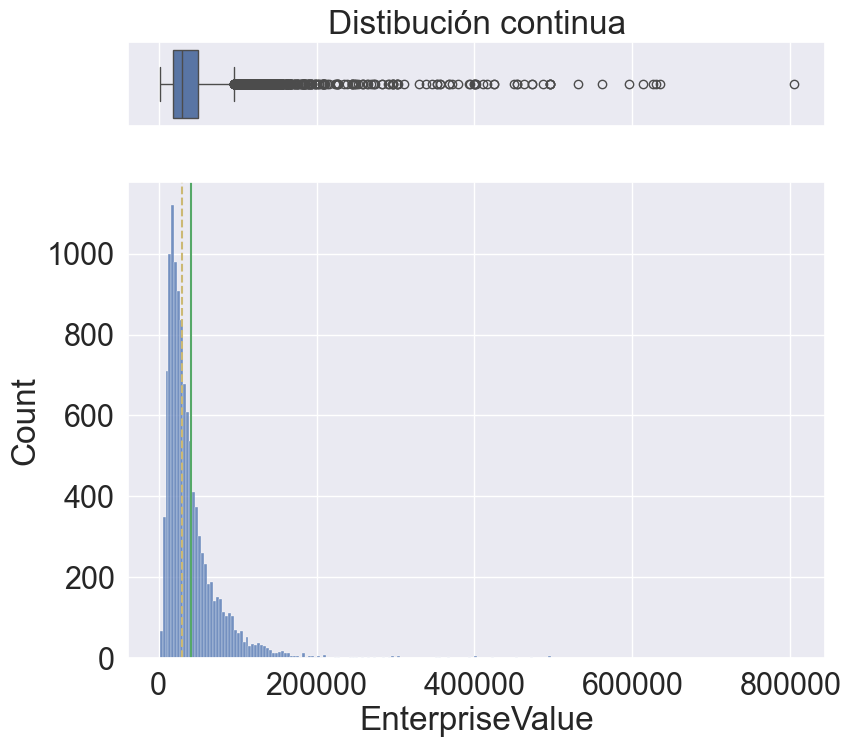

In [35]:
# Graficar
columna_a_graficar = 'EnterpriseValue' # indicar columna para el grafico
plot(df_transformed[columna_a_graficar])

In [36]:
# Transformaciones logarítmicas

columnas_a_transformar = [ 
    'Volume_Lag1',
    'CapExToRevenue',
    'DebtToEquity',
    'QuarterlyVariance_Lag1',
    'MarketCap',
    'EnterpriseValue'
    ]
for columna in columnas_a_transformar:
    df_transformed[columna] = df_transformed[columna].fillna(0)
    df_transformed[f'{columna}_Log1p'] = np.log1p(df_transformed[columna])
    df_transformed.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

NetDebtToEbitda                    73.866037
TrailingPE                         72.226545
EnterpriseToEbitda                 55.844230
PriceToBook                        35.236295
ReturnOnEquity                     32.037382
CurrentDebt                        23.730928
ReturnOnAssets                     20.078838
RelativeRevenue                    18.102689
TotalDebt                          16.113788
RelativeAssets                     15.977171
CurrentAssets                      13.383697
CurrentLiabilities                  8.833329
QuarterlyReturn_Lag1                8.139214
LongTermDebt                        7.368063
GrossProfit_TTM                     6.873943
CapExToRevenue_Log1p                4.605147
CashAndCashEquivalents              4.577474
OperatingCashFlow_TTM               4.541645
FreeCashFlow_TTM                    4.497142
Ebitda_YoY                          4.192606
TotalRevenue_TTM                    4.115833
TotalAssets                         4.102472
Depreciati

In [37]:
# Definir columnas que saltean la "winsorización"
cols_fin_clean = obtener_cols_financieras(incluirTTM=True)

columnas_intactas = cols_fin_clean + [
    # Variables de precio y ratios
    'Close',
    'Open',    
    'TrailingPE',
    'EnterpriseToEbitda',
    'PriceToBook',
    # Otras
    'Date', 
    'Ticker'   
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

## Gestión de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [38]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

In [39]:
# Coeficientes de asimetria luego de winsorizar
df_winsor.skew().sort_values(ascending=False)

RelativeRevenue                 1.717369
RelativeAssets                  1.686577
CapExToRevenue_Log1p            1.650286
ReturnOnEquity                  1.636961
NetDebtToEbitda                 1.633425
QuarterlyVariance_Lag1_Log1p    1.618182
Ebitda_YoY                      1.559478
ReturnOnAssets                  1.555679
DebtToEquity_Log1p              1.470516
Revenue_YoY                     1.428046
CurrentRatio                    1.317538
Fcf_YoY                         1.292435
QuarterlyReturn_Lag1            1.249929
Fcf_QoQ                         0.921275
OperatingMargins                0.868457
YearsSinceAdded                 0.865705
ProfitMargins                   0.846741
Ebitda_QoQ                      0.806578
FcfToEbitda                     0.709995
EnterpriseValue_Log1p           0.223751
MarketCap_Log1p                 0.153400
Revenue_QoQ                     0.120882
Volume_Lag1_Log1p               0.106778
MarketCovariance_Lag1           0.047988
CapEx_QoQ       

Cont


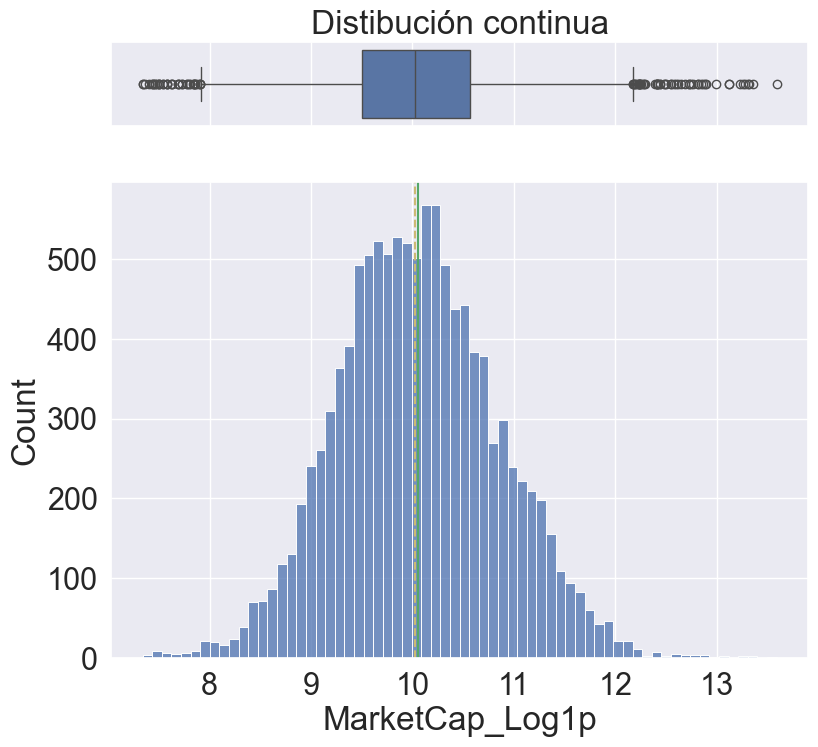

In [40]:
# Visualizar cambios
columna_a_graficar = 'MarketCap_Log1p' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [41]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
YearsSinceAdded,11366.0,15.030593,8.757649,0.000000,8.555556,13.444444,19.888889,51.000000
OperatingMargins,11366.0,0.145846,0.062957,-0.028267,0.100391,0.137161,0.181872,0.429983
ProfitMargins,11366.0,0.098811,0.052173,-0.168752,0.062973,0.091167,0.127881,0.325635
ReturnOnEquity,11366.0,0.283388,0.235727,-0.550368,0.127322,0.211889,0.348566,1.014134
ReturnOnAssets,11366.0,0.080561,0.059145,-0.127056,0.040681,0.064595,0.103144,0.290603
CurrentRatio,11366.0,1.646535,0.584792,0.386251,1.247875,1.528558,1.898563,3.852562
Revenue_YoY,11366.0,0.229923,0.613138,-0.896133,-0.163320,0.103862,0.442472,2.268262
Revenue_QoQ,11366.0,0.023344,0.095887,-0.214109,-0.019938,0.034312,0.044752,0.257426
Ebitda_YoY,11366.0,0.322616,0.811077,-0.982075,-0.215848,0.128592,0.602837,3.059740
Ebitda_QoQ,11366.0,0.159244,0.295961,-0.600033,-0.033313,0.053586,0.303377,1.317540


## Concatenación final de columnas

In [42]:
df_non_numeric_transformed = df_transformed_features.select_dtypes(exclude='number')
# Se unen variables contínuas transformadas y variables no numéricas
df_combined = pd.concat([df_non_numeric_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11366 entries, 0 to 11365
Data columns (total 55 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   CashAndCashEquivalents           11366 non-null  float64       
 1   CurrentDebt                      11366 non-null  float64       
 2   LongTermDebt                     11366 non-null  float64       
 3   TotalDebt                        11366 non-null  float64       
 4   StockholdersEquity               11366 non-null  float64       
 5   TotalAssets                      11366 non-null  float64       
 6   CurrentAssets                    11366 non-null  float64       
 7   CurrentLiabilities               11366 non-null  float64       
 8   OperatingCashFlow_TTM            11366 non-null  float64       
 9   InvestingCashFlow_TTM            11366 non-null  float64       
 10  FinancingCashFlow_TTM            11366 non-null  float64  

In [43]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")
print(f"Fichero 'clean_data.parquet' guardado en la carpeta {data_folder}")

Fichero 'clean_data.parquet' guardado en la carpeta data
